# Portfolio Construction Methods: A Comparison Study

This notebook compares six portfolio allocation methods on a 17-asset US equity universe (2021–2026) with 10bps transaction costs, monthly rebalancing, and 6-month lookback windows.

**Methods:** Hierarchical Risk Parity (HRP) (López de Prado, 2016), Risk Parity, Mean-Variance, Min-Variance, Inverse-Variance, Equal Weight  
**Benchmark:** VOO (S&P 500)  
**Statistical evaluation:** Block bootstrap Sharpe CIs, paired Sharpe difference tests, Deflated Sharpe Ratio (Bailey & López de Prado, 2014)

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_root = os.path.join(project_root, 'src')

for p in [project_root, src_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

from src.data import returns, tickers
from src.backtest import backtest_returns
from src.stats import summary_table, performance_stats, block_bootstrap_sharpe

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_DIR = os.path.join('..', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Universe: {len(tickers)} tickers')
print(f'Date range: {returns.index[0].date()} to {returns.index[-1].date()}')
print(f'Trading days: {len(returns)}')

(CVXPY) Apr 16 11:57:00 AM: Encountered unexpected exception importing solver GLPK:
ImportError("cannot import name 'glpk' from 'cvxopt' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxopt-1.3.0-py3.11-macosx-10.9-universal2.egg/cvxopt/__init__.py)")
(CVXPY) Apr 16 11:57:00 AM: Encountered unexpected exception importing solver GLPK_MI:
ImportError("cannot import name 'glpk' from 'cvxopt' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxopt-1.3.0-py3.11-macosx-10.9-universal2.egg/cvxopt/__init__.py)")
Universe: 18 tickers
Date range: 2016-09-14 to 2026-04-13
Trading days: 2407


## 1. Run backtests

All methods use a 126-day (6-month) lookback, 21-day (monthly) rebalancing, and 10bps one-way transaction costs applied proportionally to turnover at each rebalance.

In [2]:
COST_BPS = 10
LOOKBACK = 126
REBAL = 21

# Run all optimised strategies
configs = {
    'HRP':              dict(portfolio='hrp',              lw=True, plot=False),
    'Risk Parity':      dict(portfolio='risk_parity',      lw=True, plot=False),
    'Mean-Variance':    dict(portfolio='mean_variance',    lambda_risk=1, lw=True, shrink=0.3, plot=False),
    'Min-Variance':     dict(portfolio='min_variance',     lw=True, plot=False),
    'Inverse-Variance': dict(portfolio='inverse_variance', lw=True, plot=False),
}

results = {}
for name, kwargs in configs.items():
    print(f'Running {name}...')
    ret, turnover, cum_ret = backtest_returns(
        returns, lookback=LOOKBACK, rebalance_freq=REBAL, cost_bps=COST_BPS, **kwargs
    )
    results[name] = {'returns': ret, 'turnover': turnover, 'cum_returns': cum_ret}

# Align benchmarks to backtest period
backtest_start = results['HRP']['cum_returns'].index[0]
backtest_end   = results['HRP']['cum_returns'].index[-1]

equal_w = np.ones(len(returns.columns)) / len(returns.columns)
eq_ret  = (returns @ equal_w)[backtest_start:backtest_end]
results['Equal Weight'] = {'returns': eq_ret, 'turnover': 0, 'cum_returns': (1 + eq_ret).cumprod()}

voo_ret = returns['VOO'][backtest_start:backtest_end]
results['VOO'] = {'returns': voo_ret, 'turnover': 0, 'cum_returns': (1 + voo_ret).cumprod()}

print(f'\nBacktest period: {backtest_start.date()} to {backtest_end.date()}')

Running HRP...
Running Risk Parity...
Running Mean-Variance...
Running Min-Variance...
Running Inverse-Variance...

Backtest period: 2017-03-16 to 2026-03-24


## 2. Cumulative returns

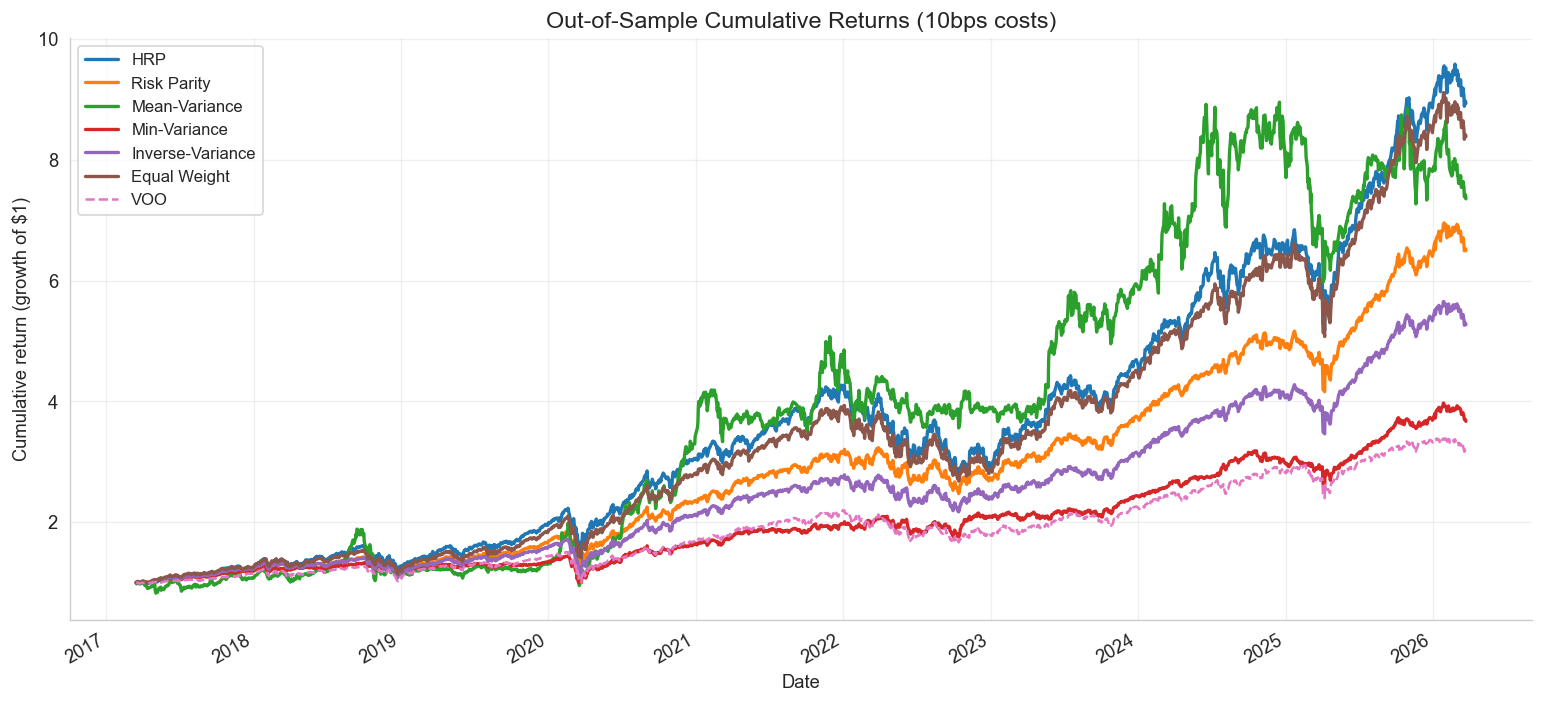

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette('tab10', n_colors=len(results))
for (name, res), color in zip(results.items(), palette):
    style = '--' if name == 'VOO' else '-'
    lw = 1.5 if name == 'VOO' else 2
    res['cum_returns'].plot(ax=ax, label=name, color=color, linestyle=style, linewidth=lw)

ax.set_ylabel('Cumulative return (growth of $1)')
ax.set_title(f'Out-of-Sample Cumulative Returns ({COST_BPS}bps costs)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'oos_backtest_comparison.png'), dpi=150)
plt.show()

## 3. Summary statistics

Bootstrap Sharpe confidence intervals (block bootstrap, B=10,000, block size=21 days) and the Deflated Sharpe Ratio (Bailey & López de Prado, 2014) correct for estimation noise and multiple testing.

In [4]:
returns_dict   = {name: res['returns']  for name, res in results.items()}
turnovers_dict = {name: res['turnover'] for name, res in results.items()}

stats_table, bootstrap_sharpes = summary_table(
    returns_dict=returns_dict, turnovers_dict=turnovers_dict, benchmark='VOO', n_boot=10000
)

display_cols = [
    'Annual Return', 'Annual Vol', 'Sharpe', 'Sharpe CI lower', 'Sharpe CI upper',
    'Max Drawdown', 'Calmar', 'Avg Turnover', 'DSR'
]
stats_table[display_cols].round(3)


,Annual Return,Annual Vol,Sharpe,Sharpe CI lower,Sharpe CI upper,Max Drawdown,Calmar,Avg Turnover,DSR
HRP,0.276,0.245,1.118,0.499,1.798,-0.351,0.786,2.720,0.973
Risk Parity,0.231,0.196,1.161,0.511,1.878,-0.326,0.710,1.102,0.978
Mean-Variance,0.248,0.351,0.809,0.125,1.530,-0.522,0.475,10.124,0.843
Min-Variance,0.155,0.164,0.963,0.301,1.699,-0.310,0.501,3.237,0.922
Inverse-Variance,0.203,0.190,1.067,0.414,1.786,-0.326,0.621,0.996,0.959
Equal Weight,0.267,0.228,1.153,0.510,1.857,-0.333,0.801,0.000,0.978
VOO,0.137,0.186,0.785,0.177,1.481,-0.340,0.404,0.000,0.825


In [5]:
# Pairwise Sharpe difference tests vs VOO
diff_cols = ['Mean Sharpe diff', 'Sharpe diff CI lower', 'Sharpe diff CI upper', 'Pct wins vs Benchmark']
stats_table[diff_cols].round(3)

,Mean Sharpe diff,Sharpe diff CI lower,Sharpe diff CI upper,Pct wins vs Benchmark
HRP,0.321,0.058,0.575,0.992
Risk Parity,0.375,0.156,0.597,0.999
Mean-Variance,0.006,-0.560,0.557,0.517
Min-Variance,0.182,-0.152,0.531,0.851
Inverse-Variance,0.281,0.103,0.466,0.998
Equal Weight,0.359,0.137,0.575,0.999
VOO,0.000,NaN,NaN,NaN


## 4. Bootstrap Sharpe distributions

Overlapping density plots show how much uncertainty exists in each method's Sharpe estimate. Wide overlap means the methods are statistically indistinguishable given 5 years of data.

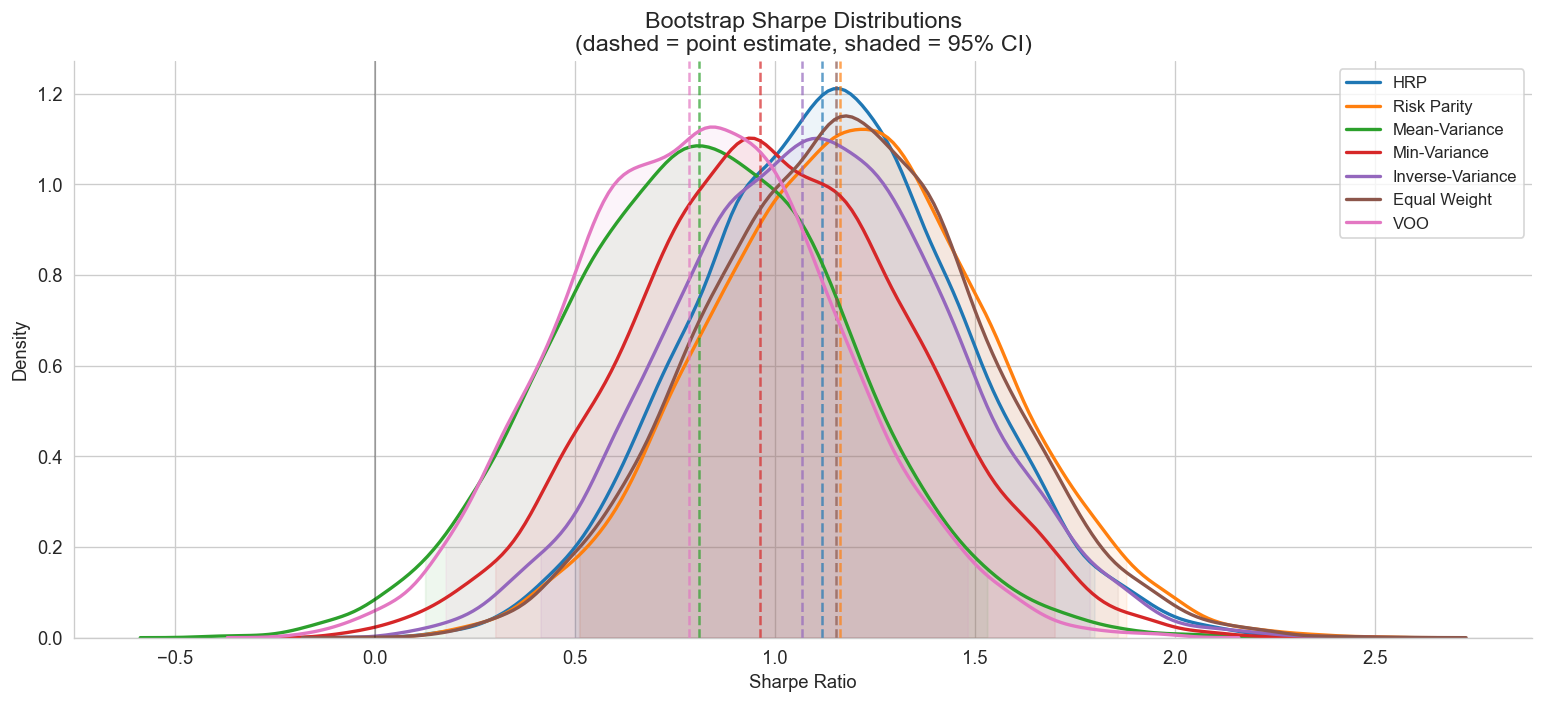

In [6]:
point_sharpes = {strat: row['Sharpe'] for strat, row in stats_table.iterrows()}

fig, ax = plt.subplots(figsize=(13, 6))

for (strat, sharpes), color in zip(bootstrap_sharpes.items(), palette):
    sns.kdeplot(sharpes, ax=ax, color=color, linewidth=2, label=strat)
    
    # Dashed vertical line at point estimate
    ax.axvline(point_sharpes[strat], color=color, linewidth=1.5, linestyle='--', alpha=0.7)
    
    # Shade 95% CI
    ci_lo, ci_hi = np.percentile(sharpes, [2.5, 97.5])
    kde = gaussian_kde(sharpes)
    x = np.linspace(ci_lo, ci_hi, 200)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.3)
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sharpe Distributions\n(dashed = point estimate, shaded = 95% CI)', fontsize=14)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bootstrap_sharpe_comparison.png'), dpi=150)
plt.show()

## 5. Turnover comparison

Turnover is the primary driver of the gap between theoretical and realised performance. Mean-Variance rebalances aggressively because it chases noisy expected-return estimates.

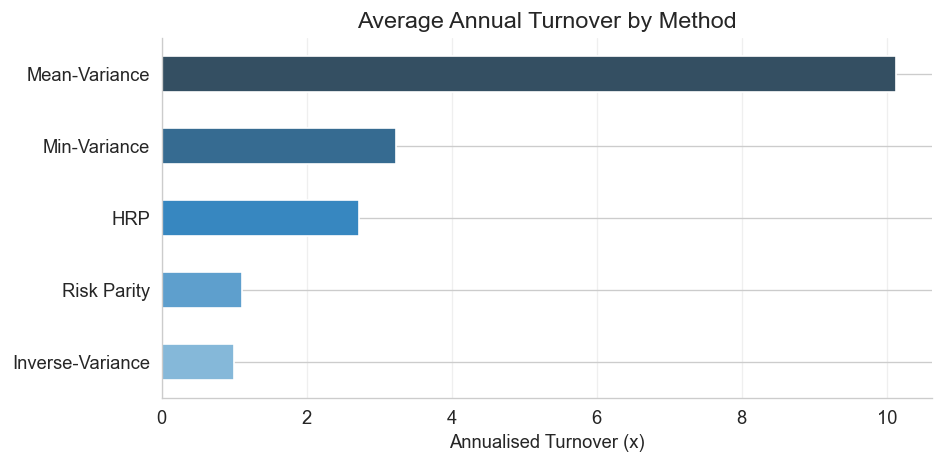

In [7]:
turnover_data = stats_table['Avg Turnover'].drop(['Equal Weight', 'VOO']).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
turnover_data.plot(kind='barh', ax=ax, color=sns.color_palette('Blues_d', len(turnover_data)))
ax.set_xlabel('Annualised Turnover (x)')
ax.set_title('Average Annual Turnover by Method', fontsize=14)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'turnover_comparison.png'), dpi=150)
plt.show()

## 6. Key findings

**1. Risk-parity methods dominate on a risk-adjusted basis.** Risk Parity (Sharpe 1.16) and HRP (1.12) lead all strategies, and both show bootstrap Sharpe difference CIs that fully exclude zero vs VOO — providing statistical evidence of outperformance.

**2. Mean-variance is the worst performer after costs.** Highest turnover by far (10.1× per rebalance) collapses the Sharpe to 0.81, and its Sharpe diff CI vs VOO straddles zero (-0.56 to 0.56), meaning no statistically distinguishable edge.

**3. HRP does not outperform plain Risk Parity or Equal Weight on this universe.** Despite higher annual return (27.6% vs 23.1%), HRP's Sharpe (1.12) trails Risk Parity (1.16) and Equal Weight (1.15), likely because the 17-asset universe is too concentrated for HRP's hierarchical clustering to add value.

**4. Equal Weight remains extremely hard to beat.** Equal Weight achieves Sharpe 1.15 with zero turnover and a DSR of 0.978 — the second highest overall. Its bootstrap CI vs VOO fully excludes zero (0.14 to 0.58), yet no optimised method meaningfully separates from it.

**5. Most methods reach statistical significance vs VOO with 10 years of data.** Risk Parity (DSR 0.978), Equal Weight (0.978), and HRP (0.973) all clear the 0.95 DSR threshold, and their % wins vs benchmark exceed 99%. Min-Variance (DSR 0.922) and Mean-Variance (0.843) do not, confirming these methods fail to justify their complexity and turnover costs.